Epoch 1/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 16s 568ms/step - accuracy: 0.5080 - loss: 0.8833 - val_accuracy: 0.6882 - val_loss: 0.9373
Epoch 2/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - accuracy: 0.6614 - loss: 0.8377 - val_accuracy: 0.8071 - val_loss: 0.9548
Epoch 3/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - accuracy: 0.7225 - loss: 0.8214 - val_accuracy: 0.9639 - val_loss: 0.9622
Epoch 4/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - accuracy: 0.7479 - loss: 0.8052 - val_accuracy: 0.9639 - val_loss: 0.9704
Epoch 5/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - accuracy: 0.7560 - loss: 0.7823 - val_accuracy: 0.9639 - val_loss: 0.9833
Epoch 6/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - accuracy: 0.7840 - loss: 0.7661 - val_accuracy: 0.9639 - val_loss: 0.9853
Epoch 7/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - accuracy: 0.8102 - loss: 0.7596 - val_accuracy: 0.9639 - val_loss: 0.9977
Epoch 8/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - accuracy: 0.8170 - loss: 0.7360 - val_accuracy: 0.9639 -

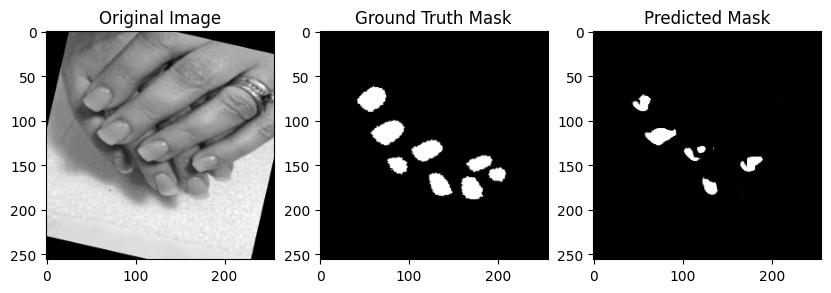

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import *
import numpy as np
import os
import cv2
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import albumentations as A

# Kích thước ảnh & batch size
IMG_SIZE = 256
BATCH_SIZE = 4  # Giảm batch size tránh lỗi OOM

# Thư mục chứa dữ liệu
IMAGE_DIR = "/content/drive/MyDrive/Colab Notebooks/hocsau/nails_segmentation-20250310T125359Z-001/nails_segmentation/images/"
MASK_DIR = "/content/drive/MyDrive/Colab Notebooks/hocsau/nails_segmentation-20250310T125359Z-001/nails_segmentation/labels/"

# Augmentation cho tập huấn luyện
augment = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.2),
    A.Rotate(limit=20, p=0.5)
])

# Hàm load ảnh và mask
def load_data(image_dir, mask_dir):
    images, masks = [], []
    image_files = sorted(os.listdir(image_dir))  # Đảm bảo ảnh và mask khớp nhau

    for file in image_files:
        img = cv2.imread(os.path.join(image_dir, file), cv2.IMREAD_GRAYSCALE)  # Chuyển sang grayscale
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE)) / 255.0  # Chuẩn hóa

        mask = cv2.imread(os.path.join(mask_dir, file), cv2.IMREAD_GRAYSCALE)
        mask = cv2.resize(mask, (IMG_SIZE, IMG_SIZE)) / 255.0  # Chuẩn hóa

        # Áp dụng augmentation cho ảnh huấn luyện
        augmented = augment(image=img, mask=mask)
        img = augmented["image"]
        mask = augmented["mask"]

        img = np.expand_dims(img, axis=-1)  # Đưa về shape (256, 256, 1)
        mask = np.expand_dims(mask, axis=-1)

        images.append(img)
        masks.append(mask)

    return np.array(images), np.array(masks)

# Load dữ liệu
images, masks = load_data(IMAGE_DIR, MASK_DIR)
X_train, X_val, y_train, y_val = train_test_split(images, masks, test_size=0.2, random_state=42)

# Xây dựng mô hình U-Net tối ưu
def build_unet():
    inputs = Input((IMG_SIZE, IMG_SIZE, 1))  # Ảnh grayscale

    # Encoder
    c1 = Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
    c1 = BatchNormalization()(c1)
    c1 = Conv2D(32, (3, 3), activation='relu', padding='same')(c1)
    c1 = BatchNormalization()(c1)
    p1 = MaxPooling2D((2, 2))(c1)

    c2 = Conv2D(64, (3, 3), activation='relu', padding='same')(p1)
    c2 = BatchNormalization()(c2)
    c2 = Conv2D(64, (3, 3), activation='relu', padding='same')(c2)
    c2 = BatchNormalization()(c2)
    p2 = MaxPooling2D((2, 2))(c2)

    c3 = Conv2D(128, (3, 3), activation='relu', padding='same')(p2)
    c3 = BatchNormalization()(c3)
    c3 = Conv2D(128, (3, 3), activation='relu', padding='same')(c3)
    c3 = BatchNormalization()(c3)

    # Decoder
    u4 = UpSampling2D((2, 2))(c3)
    u4 = Conv2D(64, (3, 3), activation='relu', padding='same')(u4)
    u4 = BatchNormalization()(u4)
    u4 = Concatenate()([u4, c2])

    u5 = UpSampling2D((2, 2))(u4)
    u5 = Conv2D(32, (3, 3), activation='relu', padding='same')(u5)
    u5 = BatchNormalization()(u5)
    u5 = Concatenate()([u5, c1])

    outputs = Conv2D(1, (1, 1), activation='sigmoid')(u5)

    model = keras.Model(inputs, outputs)
    return model

# Hàm Dice Loss giúp phân vùng tốt hơn
def dice_loss(y_true, y_pred):
    smooth = 1.0
    y_true_f = tf.keras.backend.flatten(y_true)
    y_pred_f = tf.keras.backend.flatten(y_pred)
    intersection = tf.keras.backend.sum(y_true_f * y_pred_f)
    return 1 - (2. * intersection + smooth) / (tf.keras.backend.sum(y_true_f) + tf.keras.backend.sum(y_pred_f) + smooth)

# Compile & train
model = build_unet()
model.compile(optimizer='adam', loss=dice_loss, metrics=['accuracy'])

# Dùng `tf.data` để load dữ liệu hiệu quả hơn
train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train)).batch(BATCH_SIZE).prefetch(1)
val_dataset = tf.data.Dataset.from_tensor_slices((X_val, y_val)).batch(BATCH_SIZE).prefetch(1)

history = model.fit(train_dataset, validation_data=val_dataset, epochs=50)

# Dự đoán và hiển thị kết quả
sample_idx = 0
sample_img = X_val[sample_idx]
sample_mask = y_val[sample_idx]
pred_mask = model.predict(np.expand_dims(sample_img, axis=0))[0]

plt.figure(figsize=(10,5))
plt.subplot(1,3,1)
plt.imshow(sample_img.squeeze(), cmap="gray")
plt.title("Original Image")
plt.subplot(1,3,2)
plt.imshow(sample_mask.squeeze(), cmap="gray")
plt.title("Ground Truth Mask")
plt.subplot(1,3,3)
plt.imshow(pred_mask.squeeze(), cmap="gray")
plt.title("Predicted Mask")
plt.show()


In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import segmentation_models_pytorch as smp
import numpy as np
import os
from tqdm import tqdm
from PIL import Image
from torchvision import transforms

# ---- Cấu hình ----
IMAGE_SIZE = (256, 256)  # Resize ảnh về kích thước cố định
BATCH_SIZE = 4
EPOCHS = 30
LEARNING_RATE = 1e-4
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MODEL_TYPE = "deeplabv3"  # Chọn "unet" hoặc "deeplabv3"

# ---- Dataset Class ----
class NailSegmentationDataset(Dataset):
    def __init__(self, images_dir, masks_dir, transform=None):
        self.images_dir = images_dir
        self.masks_dir = masks_dir
        self.image_files = sorted(os.listdir(images_dir))
        self.transform = transform

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        image_name = self.image_files[idx]
        image_path = os.path.join(self.images_dir, image_name)
        mask_path = os.path.join(self.masks_dir, image_name)

        image = Image.open(image_path).convert("RGB")
        mask = Image.open(mask_path).convert("L")

        if self.transform:
            image, mask = self.transform(image, mask)

        return image, mask

# ---- Transformations ----
def transform(image, mask):
    transform_image = transforms.Compose([
        transforms.Resize(IMAGE_SIZE),
        transforms.ToTensor(),
    ])
    transform_mask = transforms.Compose([
        transforms.Resize(IMAGE_SIZE, interpolation=Image.NEAREST),
        transforms.ToTensor(),
    ])
    return transform_image(image), transform_mask(mask)

# ---- Load Data ----
data_dir = "/content/drive/MyDrive/Colab Notebooks/hocsau/nails_segmentation-20250310T125359Z-001/nails_segmentation"
train_dataset = NailSegmentationDataset(
    os.path.join(data_dir, "images"),
    os.path.join(data_dir, "labels"),
    transform=transform
)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

# ---- Model ----
if MODEL_TYPE == "unet":
    model = smp.Unet(
        encoder_name="resnet34", encoder_weights="imagenet", in_channels=3, classes=1
    )
else:
    model = smp.DeepLabV3(
        encoder_name="resnet34", encoder_weights="imagenet", in_channels=3, classes=1
    )
model.to(DEVICE)

# ---- Loss & Optimizer ----
loss_fn = lambda pred, target: smp.losses.DiceLoss(mode="binary")(pred, target) + nn.BCEWithLogitsLoss()(pred, target)

optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# ---- Training Loop ----
best_dice = 0.0
for epoch in range(EPOCHS):
    model.train()
    epoch_loss = 0.0
    dice_scores = []

    for images, masks in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}"):
        images, masks = images.to(DEVICE), masks.to(DEVICE)
        optimizer.zero_grad()

        outputs = model(images)
        loss = loss_fn(outputs, masks)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

        pred_masks = torch.sigmoid(outputs) > 0.5
        dice_score = (2 * (pred_masks * masks).sum()) / ((pred_masks + masks).sum() + 1e-8)
        dice_scores.append(dice_score.item())

    mean_dice = np.mean(dice_scores)
    print(f"Epoch {epoch+1}: Loss = {epoch_loss:.4f}, Dice Score = {mean_dice:.4f}")

    # Lưu mô hình tốt nhất
    if mean_dice > best_dice:
        best_dice = mean_dice
        torch.save(model.state_dict(), "nail_segmentation_best.pth")
        print("✅ Mô hình tốt nhất đã được lưu!")

Epoch 1/30: 100%|██████████| 13/13 [00:04<00:00,  3.03it/s]


Epoch 1: Loss = 20.5533, Dice Score = 0.1625
✅ Mô hình tốt nhất đã được lưu!


Epoch 2/30: 100%|██████████| 13/13 [00:04<00:00,  3.14it/s]


Epoch 2: Loss = 19.0996, Dice Score = 0.2480
✅ Mô hình tốt nhất đã được lưu!


Epoch 3/30: 100%|██████████| 13/13 [00:04<00:00,  3.22it/s]


...

Epoch 28: Loss = 3.9928, Dice Score = 0.8961


Epoch 29/30: 100%|██████████| 13/13 [00:04<00:00,  3.07it/s]


Epoch 29: Loss = 3.7148, Dice Score = 0.9057
✅ Mô hình tốt nhất đã được lưu!


Epoch 30/30: 100%|██████████| 13/13 [00:03<00:00,  3.40it/s]

Epoch 30: Loss = 3.6027, Dice Score = 0.9053


In [19]:
import torch
import numpy as np
import time
from tqdm import tqdm
from torch.utils.data import DataLoader
from torchvision import transforms
from PIL import Image
import os
import segmentation_models_pytorch as smp  # Dùng Unet hoặc DeepLabV3

# ✅ Định nghĩa Dataset để load ảnh và nhãn
class CustomDataset(torch.utils.data.Dataset):
    def __init__(self, images_dir, labels_dir, transform=None):
        self.images_dir = images_dir
        self.labels_dir = labels_dir
        self.transform = transform
        self.image_files = sorted(os.listdir(images_dir))
        self.to_tensor = transforms.ToTensor()  # Chuyển PIL Image thành Tensor

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        image_name = self.image_files[idx]
        image_path = os.path.join(self.images_dir, image_name)
        label_path = os.path.join(self.labels_dir, image_name)

        image = Image.open(image_path).convert('RGB')
        label = Image.open(label_path).convert('L')  # Nhãn ở dạng grayscale

        # Resize ảnh và nhãn về cùng một kích thước
        if self.transform:
            image, label = self.transform(image, label)

        # Chuyển đổi từ PIL Image sang Tensor
        image = self.to_tensor(image)
        label = torch.tensor(np.array(label) / 255.0, dtype=torch.float32).unsqueeze(0)  # Nhãn về khoảng [0,1]

        return image, label

# ✅ Hàm resize cho cả ảnh và nhãn
def resize_image_and_mask(image, mask, size=(256, 256)):
    image = image.resize(size, Image.BILINEAR)
    mask = mask.resize(size, Image.NEAREST)  # Dùng phương pháp NEAREST cho nhãn
    return image, mask

# ✅ Hàm tải mô hình từ file .pth
def load_model(model_path):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    try:
        checkpoint = torch.load(model_path, map_location=device)
    except FileNotFoundError:
        print("❌ Không tìm thấy mô hình. Kiểm tra lại đường dẫn.")
        return None

    print("🔍 Phát hiện mô hình DeepLabV3. Đang khởi tạo...")
    model = smp.DeepLabV3(
        encoder_name="resnet34",
        encoder_weights=None,
        in_channels=3,
        classes=1
    )

    model.load_state_dict(checkpoint, strict=False)
    model.to(device)
    model.eval()
    print("✅ Mô hình đã tải thành công!")

    return model

# ✅ Hàm đánh giá mô hình
def evaluate_model(test_images_dir, test_masks_dir, model_path):
    model = load_model(model_path)
    if model is None:
        return

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # Load tập dữ liệu test
    test_dataset = CustomDataset(
        images_dir=test_images_dir,
        labels_dir=test_masks_dir,
        transform=resize_image_and_mask
    )

    if len(test_dataset) == 0:
        print("❌ Tập test rỗng. Kiểm tra lại dữ liệu.")
        return

    test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

    # Lưu trữ các chỉ số
    dice_scores = []
    iou_scores = []
    accuracies = []

    start_time = time.time()

    for images, masks in tqdm(test_loader, desc="🔍 Đang đánh giá..."):
        images = images.to(device)
        masks = masks.to(device)

        with torch.no_grad():
            outputs = model(images)
            pred_masks = torch.sigmoid(outputs)  # Dự đoán xác suất

        pred_binary = (pred_masks > 0.5).float()  # Chuyển thành mask nhị phân

        # ✅ Tính Dice Score
        intersection = (pred_binary * masks).sum()
        union = pred_binary.sum() + masks.sum()
        dice = (2. * intersection) / (union + 1e-8)
        dice_scores.append(dice.item())

        # ✅ Tính IoU (Intersection over Union)
        iou = intersection / (union - intersection + 1e-8)
        iou_scores.append(iou.item())

        # ✅ Tính Accuracy
        correct = (pred_binary == masks).float().mean()
        accuracies.append(correct.item())

    # ✅ Tính toán trung bình các chỉ số
    mean_dice = np.mean(dice_scores)
    mean_iou = np.mean(iou_scores)
    mean_accuracy = np.mean(accuracies)

    end_time = time.time()
    elapsed_time = end_time - start_time

    # ✅ In kết quả
    print("\n📊 **Kết quả đánh giá**")
    print(f"✅ Dice Score trung bình: {mean_dice:.4f}")
    print(f"✅ IoU Score trung bình: {mean_iou:.4f}")
    print(f"✅ Độ chính xác trung bình: {mean_accuracy:.4f}")
    print(f"⏱️ Thời gian đánh giá: {elapsed_time:.2f} giây")

    return mean_dice, mean_iou, mean_accuracy

# ✅ Đường dẫn tập test
test_images_dir = '/content/drive/MyDrive/Colab Notebooks/hocsau/nails_segmentation-20250310T125359Z-001/nails_segmentation/images'
test_masks_dir = '/content/drive/MyDrive/Colab Notebooks/hocsau/nails_segmentation-20250310T125359Z-001/nails_segmentation/labels'
model_path = '/content/nail_segmentation_best.pth'

# ✅ Gọi hàm đánh giá
evaluate_model(test_images_dir, test_masks_dir, model_path)


<ipython-input-19-58f8557db712>:52: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(model_path, map_location=device)


🔍 Phát hiện mô hình DeepLabV3. Đang khởi tạo...
✅ Mô hình đã tải thành công!


🔍 Đang đánh giá...: 100%|██████████| 52/52 [00:02<00:00, 22.71it/s]


📊 **Kết quả đánh giá**
✅ Dice Score trung bình: 0.8819
✅ IoU Score trung bình: 0.7941
✅ Độ chính xác trung bình: 0.9911
⏱️ Thời gian đánh giá: 2.29 giây


(0.8818792631992927, 0.7941343738482549, 0.9911050062913161)

<ipython-input-30-771196637323>:18: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path, map_location=DEVICE))


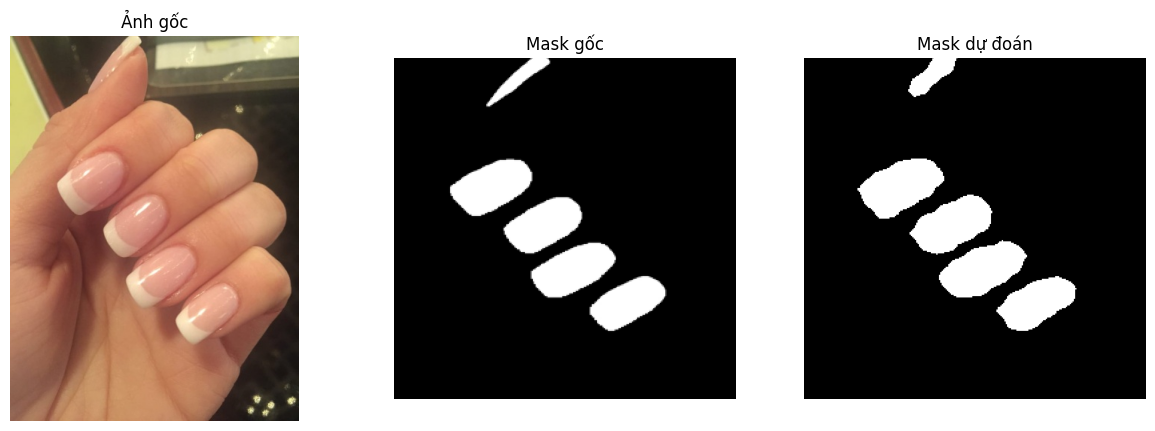

In [30]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from torchvision import transforms
from PIL import Image
import os
import segmentation_models_pytorch as smp

# Cấu hình
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MODEL_PATH = "/content/nail_segmentation_best.pth"  # Thay bằng đường dẫn mô hình của bạn
IMAGE_DIR = "/content/drive/MyDrive/Colab Notebooks/hocsau/nails_segmentation-20250310T125359Z-001/nails_segmentation/images"   # Thư mục ảnh gốc
LABEL_DIR = "/content/drive/MyDrive/Colab Notebooks/hocsau/nails_segmentation-20250310T125359Z-001/nails_segmentation/labels"   # Thư mục mask gốc

# Load model
def load_model(model_path):
    model = smp.DeepLabV3(encoder_name="resnet34", encoder_weights=None, in_channels=3, classes=1)
    model.load_state_dict(torch.load(model_path, map_location=DEVICE))
    model.to(DEVICE)
    model.eval()
    return model

# Hàm dự đoán mask
def predict_mask(model, image_path):
    image = Image.open(image_path).convert("RGB")
    transform = transforms.Compose([transforms.Resize((256, 256)), transforms.ToTensor()])
    image_tensor = transform(image).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        output = model(image_tensor)
        mask = torch.sigmoid(output).squeeze().cpu().numpy()

    return image, mask

# Hiển thị kết quả
def visualize_prediction(image_path, label_path, mask_threshold=0.5):
    model = load_model(MODEL_PATH)
    image, mask = predict_mask(model, image_path)

    # Load mask gốc
    mask_gt = Image.open(label_path).convert("L").resize((256, 256))  # Resize cho khớp kích thước

    # Xử lý mask dự đoán
    mask_pred = np.where(mask > mask_threshold, 255, 0).astype(np.uint8)
    mask_pred = Image.fromarray(mask_pred)

    # Vẽ ảnh gốc, mask gốc và mask dự đoán
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    axes[0].imshow(image)
    axes[0].set_title("Ảnh gốc")
    axes[0].axis("off")

    axes[1].imshow(mask_gt, cmap="gray")  # Hiển thị mask gốc
    axes[1].set_title("Mask gốc")
    axes[1].axis("off")

    axes[2].imshow(mask_pred, cmap="gray")  # Hiển thị mask dự đoán (đen/trắng)
    axes[2].set_title("Mask dự đoán")
    axes[2].axis("off")

    plt.show()

# Chạy thử với một ảnh trong thư mục
image_name = sorted(os.listdir(IMAGE_DIR))[1]  # Chọn một ảnh trong thư mục
test_image_path = os.path.join(IMAGE_DIR, image_name)
test_label_path = os.path.join(LABEL_DIR, image_name)

visualize_prediction(test_image_path, test_label_path)
